<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.0 Data Download and Time Alignment


In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import gc

# ==========================================
# 1. Download and Load Data
# ==========================================
print("1. Downloading dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("martinsn/high-frequency-crypto-limit-order-book-data")
print(f"Dataset downloaded to: {dataset_path}")

# ── Load BTC (prediction target + LOB features) ──
btc_path = os.path.join(dataset_path, 'BTC_1sec.csv')
print(f"Loading BTC data from: {btc_path} ...")
btc = pd.read_csv(btc_path, nrows=100000)
print(f"BTC loaded. Shape: {btc.shape}")

# ── Load ETH (cross-asset market state features) ──
eth_path = os.path.join(dataset_path, 'ETH_1sec.csv')
print(f"Loading ETH data from: {eth_path} ...")
eth = pd.read_csv(eth_path, nrows=100000)
print(f"ETH loaded. Shape: {eth.shape}")


1. Downloading dataset via kagglehub...
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
Dataset downloaded to: /kaggle/input/high-frequency-crypto-limit-order-book-data
Loading BTC data from: /kaggle/input/high-frequency-crypto-limit-order-book-data/BTC_1sec.csv ...
BTC loaded. Shape: (100000, 156)
Loading ETH data from: /kaggle/input/high-frequency-crypto-limit-order-book-data/ETH_1sec.csv ...
ETH loaded. Shape: (100000, 156)


##1.1 Time Alignment

In [2]:
# ==========================================
# 2. Time Alignment (floor to second)
# ==========================================
print("\n2. Aligning BTC and ETH on second-level timestamps...")

btc['system_time'] = pd.to_datetime(btc['system_time'], utc=True)
eth['system_time'] = pd.to_datetime(eth['system_time'], utc=True)

# Floor microsecond timestamps to second for alignment
btc['time_key'] = btc['system_time'].dt.floor('s')
eth['time_key'] = eth['system_time'].dt.floor('s')

# Keep only needed ETH columns before merge
eth_slim = eth[['time_key', 'midpoint', 'spread',
                 'bids_notional_0', 'asks_notional_0']].copy()

eth_slim = eth_slim.rename(columns={
    'midpoint':        'eth_midpoint',
    'spread':          'eth_spread',
    'bids_notional_0': 'eth_bids_notional_0',
    'asks_notional_0': 'eth_asks_notional_0',
})

# Inner join on second-level key
df = pd.merge(btc, eth_slim, on='time_key', how='inner')
df = df.drop(columns=['time_key'])
df = df.reset_index(drop=True)
print(f"After merge: {df.shape}  (kept {len(df):,} rows)")



2. Aligning BTC and ETH on second-level timestamps...
After merge: (99972, 160)  (kept 99,972 rows)


#2.0 Feature Engineering and PCA

In [3]:
# ==========================================
# 3. Feature Engineering
# ==========================================
print("\n3. Constructing microstructure and market state features...")

# ── BTC ──
df['mid_price'] = df['midpoint']

df['btc_oimb_1'] = ((df['bids_notional_0'] - df['asks_notional_0']) /
                    (df['bids_notional_0'] + df['asks_notional_0'] + 1e-8))

window_short, window_long = 10, 60
df['log_return']         = np.log(df['mid_price'] / df['mid_price'].shift(1))
df['btc_volatility_10s'] = df['log_return'].rolling(window=window_short).std()
df['btc_volatility_60s'] = df['log_return'].rolling(window=window_long).std()
df['btc_momentum_10s']   = df['log_return'].rolling(window=window_short).sum()
df['btc_momentum_60s']   = df['log_return'].rolling(window=window_long).sum()

# ── ETH cross-asset ──
df['eth_log_return']     = np.log(df['eth_midpoint'] / df['eth_midpoint'].shift(1))
df['eth_oimb_1']         = ((df['eth_bids_notional_0'] - df['eth_asks_notional_0']) /
                             (df['eth_bids_notional_0'] + df['eth_asks_notional_0'] + 1e-8))
df['eth_volatility_10s'] = df['eth_log_return'].rolling(window=window_short).std()
df['eth_volatility_60s'] = df['eth_log_return'].rolling(window=window_long).std()
df['eth_momentum_10s']   = df['eth_log_return'].rolling(window=window_short).sum()
df['eth_momentum_60s']   = df['eth_log_return'].rolling(window=window_long).sum()

# ── BTC-ETH cross features ──
df['btc_eth_momentum_diff_10s'] = df['btc_momentum_10s'] - df['eth_momentum_10s']
df['btc_eth_momentum_diff_60s'] = df['btc_momentum_60s'] - df['eth_momentum_60s']
df['btc_eth_vol_ratio_10s']     = (df['btc_volatility_10s'] /
                                   (df['eth_volatility_10s'] + 1e-8))

# ── Prediction labels (BTC, next 10 seconds) ──
prediction_horizon = 30 #从10改到30
label_threshold = 0.0002  # 从0.00005提高到0.0002

df['future_return'] = ((df['mid_price'].shift(-prediction_horizon) - df['mid_price'])
                       / df['mid_price'])
df['label'] = np.select(
    [df['future_return'] > label_threshold,
     df['future_return'] < -label_threshold],
    [1, -1],
    default=0
)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after dropna: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")



3. Constructing microstructure and market state features...
Shape after dropna: (99882, 178)
Label distribution:
label
-1    31492
 0    37087
 1    31303
Name: count, dtype: int64


##2.1 PCA

In [4]:
# ==========================================
# 4. PCA on BTC LOB features
# ==========================================
print("\n4. Executing PCA on BTC LOB features...")

lob_features = []
for i in range(15):
    lob_features.extend([
        f'bids_distance_{i}', f'asks_distance_{i}',
        f'bids_notional_{i}', f'asks_notional_{i}'
    ])

X_lob     = df[lob_features].values
split_idx = int(len(df) * 0.8)

X_train_lob = X_lob[:split_idx]
X_test_lob  = X_lob[split_idx:]

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lob)
X_test_scaled  = scaler.transform(X_test_lob)

pca         = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA: {len(lob_features)} features → {pca.n_components_} components")



4. Executing PCA on BTC LOB features...
PCA: 60 features → 30 components


##2.2 Final Data Structure

In [5]:
# ==========================================
# 5. Final Dataset Assembly
# ==========================================
print("\n5. Generating final feature dataset...")

pca_cols = [f'pca_{i+1}' for i in range(pca.n_components_)]
pca_df   = pd.DataFrame(
    np.vstack((X_train_pca, X_test_pca)),
    columns=pca_cols,
    index=df.index
)

market_state_cols = [
    # BTC
    'spread', 'btc_oimb_1',
    'btc_volatility_10s', 'btc_volatility_60s',
    'btc_momentum_10s',   'btc_momentum_60s',
    # ETH
    'eth_spread', 'eth_oimb_1',
    'eth_volatility_10s', 'eth_volatility_60s',
    'eth_momentum_10s',   'eth_momentum_60s',
    # BTC-ETH divergence
    'btc_eth_momentum_diff_10s', 'btc_eth_momentum_diff_60s',
    'btc_eth_vol_ratio_10s',
]

X_final = pd.concat([pca_df, df[market_state_cols]], axis=1)
Y_final = df['label']

print(f"Final X shape: {X_final.shape}")
print(f"Final Y shape: {Y_final.shape}")

gc.collect()
display(X_final.head())


5. Generating final feature dataset...
Final X shape: (99882, 45)
Final Y shape: (99882,)


,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,...,btc_momentum_60s,eth_spread,eth_oimb_1,eth_volatility_10s,eth_volatility_60s,eth_momentum_10s,eth_momentum_60s,btc_eth_momentum_diff_10s,btc_eth_momentum_diff_60s,btc_eth_vol_ratio_10s
0,1.996466,7.441901,0.051026,1.310785,-1.132861,1.934077,0.290054,-0.855189,0.307409,-0.335799,...,-0.003200,0.01,-0.396305,0.000207,0.000253,-0.000506,-0.002474,-0.000195,-0.000726,1.028826
1,-3.523406,7.081429,-2.192630,0.524562,-2.142143,2.045603,0.518768,1.085197,0.015108,0.246824,...,-0.003156,0.39,-0.679389,0.000199,0.000253,-0.000605,-0.002443,-0.000055,-0.000713,1.076590
2,2.390065,9.201086,4.306024,1.920790,-2.437697,0.732662,-0.236307,0.791339,-0.354915,1.192466,...,-0.003354,0.03,0.522530,0.000204,0.000253,-0.000389,-0.002347,-0.000442,-0.001007,1.068719
3,-5.631189,13.421371,-3.046557,-0.566219,-0.784809,-0.655620,-0.353740,-1.108371,-0.805785,0.413281,...,-0.003425,0.36,-0.196982,0.000167,0.000253,-0.000114,-0.002456,-0.000544,-0.000969,1.256562
4,-6.413568,12.155310,-1.251804,0.171633,-1.686938,0.688295,0.255224,-0.199692,0.383638,1.423824,...,-0.003336,0.21,0.704133,0.000168,0.000253,-0.000043,-0.002489,-0.000218,-0.000847,1.169641


##2.3 Visualization of PCA

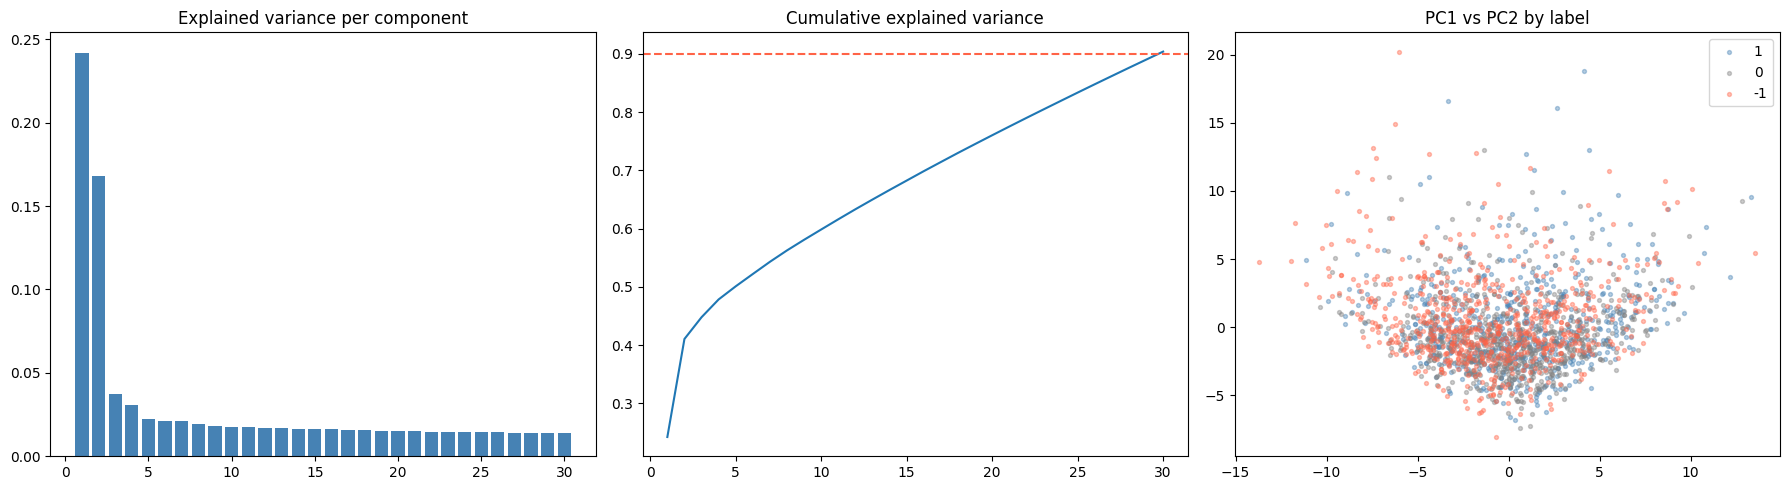

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree + cumulative
axes[0].bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title('Explained variance per component')

cum = pca.explained_variance_ratio_.cumsum()
axes[1].plot(range(1, pca.n_components_+1), cum)
axes[1].axhline(0.90, color='tomato', linestyle='--')
axes[1].set_title('Cumulative explained variance')

# Scatter PC1 vs PC2 (train set, downsampled)
idx = np.random.choice(len(X_train_pca), 2000, replace=False)
colors = {1:'steelblue', 0:'gray', -1:'tomato'}
y_train = Y_final.iloc[:split_idx]
for label, color in colors.items():
    mask = y_train.iloc[idx] == label
    axes[2].scatter(X_train_pca[idx][mask, 0], X_train_pca[idx][mask, 1],
                    c=color, alpha=0.4, s=8, label=label)
axes[2].set_title('PC1 vs PC2 by label')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3.0 CNN model builder

In [7]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ╔══════════════════════════════════════════════════════════════════╗
# ║              ★  CHOOSE YOUR INPUTS HERE  ★                      ║
# ║                                                                  ║
# ║  FEATURE_SET — which features to train on:                       ║
# ║    "full"    → PCA components + market state features (X_final)  ║
# ║    "pca"     → PCA components only (no market state features)    ║
# ║    "raw"     → original 60 LOB features (no PCA, no market)      ║
# ╚══════════════════════════════════════════════════════════════════╝
FEATURE_SET = "raw"    # ← change me: "full" | "pca" | "raw"

# ── Config ────────────────────────────────────────────────────────────────────
SEED        = 42
SEQ_LEN     = 30        # sliding window length (same as Transformer)
N_FILTERS   = 64        # base number of CNN channels
KERNEL_SIZE = 3         # convolution kernel size
N_BLOCKS    = 3         # number of residual blocks
DROPOUT     = 0.3       #我从0.1改到0.3
BATCH_SIZE  = 256
EPOCHS      = 30
LR          = 3e-4
PATIENCE    = 6
WD = 1e-3 #weight_decay

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Feature Selection  (identical logic to Transformer notebook)
# ══════════════════════════════════════════════════════════════════════════════
def select_features(feature_set: str):
    """
    Returns numpy arrays (X, y) based on the chosen feature set.

    Reads X_final, Y_final, df from the notebook scope (same as Transformer).

    "full" → X_final          (PCA cols + market state cols)
    "pca"  → PCA cols only    (columns starting with 'pca_')
    "raw"  → original 60 LOB  (bids/asks distance & notional, 15 levels)
    """
    if feature_set == "full":
        print("Feature set : FULL  (PCA + market state)")
        X = X_final.values.astype(np.float32)

    elif feature_set == "pca":
        pca_cols = [c for c in X_final.columns if c.startswith("pca_")]
        print(f"Feature set : PCA only  ({len(pca_cols)} components)")
        X = X_final[pca_cols].values.astype(np.float32)

    elif feature_set == "raw":
        lob_cols = []
        for i in range(15):
            lob_cols += [f"bids_distance_{i}", f"asks_distance_{i}",
                         f"bids_notional_{i}", f"asks_notional_{i}"]
        print(f"Feature set : RAW LOB  ({len(lob_cols)} features, no PCA)")
        X = df[lob_cols].values.astype(np.float32)

    else:
        raise ValueError(f"Unknown feature_set '{feature_set}'. Choose 'full', 'pca', or 'raw'.")

    y = (Y_final.values + 1).astype(np.int64)   # {-1,0,1} → {0,1,2}
    print(f"X shape: {X.shape}  |  y shape: {y.shape}")
    return X, y


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Dataset & DataLoaders  (identical to Transformer notebook)
# ══════════════════════════════════════════════════════════════════════════════
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        # Shape: (seq_len, n_features) — will be permuted to (n_features, seq_len) for CNN
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


def build_loaders(X, y):
    """Chronological 80/20 split → normalise → sliding-window DataLoaders."""
    split  = int(len(X) * 0.8)
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X[:split])
    X_te   = scaler.transform(X[split:])
    y_tr, y_te = y[:split], y[split:]

    counts  = np.bincount(y_tr, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples: {len(train_loader.dataset):,}  |  "
          f"Test samples: {len(test_loader.dataset):,}")
    print(f"Class weights (down/flat/up): {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — CNN Model
# ══════════════════════════════════════════════════════════════════════════════

# ── 3a. Core building blocks ──────────────────────────────────────────────────

class ResidualBlock1D(nn.Module):
    """
    One temporal residual block:
        Input (C_in, T)
          → Conv1d + BN + GELU
          → Conv1d + BN
          + skip connection (1×1 conv if C_in ≠ C_out)
          → GELU → Dropout

    'same' padding keeps the time dimension T unchanged throughout.
    """
    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int = 3, dropout: float = 0.1):
        super().__init__()
        pad = kernel_size // 2           # 'same' padding for odd kernels

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(out_channels)

        # Skip connection: 1×1 conv when channel dimensions differ
        self.skip = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

        self.act     = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, C_in, T)
        residual = self.skip(x)

        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        return self.dropout(self.act(out + residual))


class TemporalBlock(nn.Module):
    """
    Dilated causal convolution block (TCN-style).
    Uses exponentially growing dilation to capture long-range dependencies
    without increasing kernel size.

        dilation = 2^block_index  →  receptive field grows as 1, 2, 4, 8 …
    """
    def __init__(self, channels: int, kernel_size: int = 3,
                 dilation: int = 1, dropout: float = 0.1):
        super().__init__()
        # Causal padding: pad only the left side so t depends only on t-k..t
        pad = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(channels, channels, kernel_size,
                               padding=pad, dilation=dilation)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size,
                               padding=pad, dilation=dilation)
        self.bn2   = nn.BatchNorm1d(channels)

        self.act     = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.chomp   = lambda x, p: x[:, :, :-p] if p > 0 else x  # remove future leak

    def forward(self, x):
        pad = self.conv1.padding[0]
        out = self.act(self.bn1(self.chomp(self.conv1(x), pad)))
        out = self.bn2(self.chomp(self.conv2(out), pad))
        return self.dropout(self.act(out + x))          # residual (same channel)


# ── 3b. Full CNN model ────────────────────────────────────────────────────────

class LOBCNN(nn.Module):
    """
    Architecture
    ────────────
    Input  : (B, T=30, F)          — batch, time, features
    Permute: (B, F, T)             — Conv1d expects (B, C, L)

    Stage 1 — Feature projection
        Linear: F → N_FILTERS  (applied feature-wise via Conv1d k=1)

    Stage 2 — Residual blocks
        N_BLOCKS residual blocks, each doubling channels up to 4×N_FILTERS
        (64 → 128 → 256 → 256 for N_BLOCKS=3)

    Stage 3 — Dilated temporal blocks
        N_BLOCKS dilated blocks (dilation 1,2,4) for long-range context

    Stage 4 — Global average pooling over time → (B, C)

    Stage 5 — Classification head
        Linear(C, C//2) → GELU → Dropout → Linear(C//2, 3)
    """
    def __init__(self, n_features: int):
        super().__init__()

        # Stage 1: project raw features to filter space (pointwise conv = Linear)
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_features, N_FILTERS, kernel_size=1),
            nn.BatchNorm1d(N_FILTERS),
            nn.GELU()
        )

        # Stage 2: stacked residual blocks with channel expansion
        res_blocks = []
        in_ch = N_FILTERS
        for i in range(N_BLOCKS):
            out_ch = min(N_FILTERS * (2 ** i), N_FILTERS * 4)   # cap at 4×
            res_blocks.append(ResidualBlock1D(in_ch, out_ch, KERNEL_SIZE, DROPOUT))
            in_ch = out_ch
        self.res_blocks = nn.Sequential(*res_blocks)

        # Stage 3: dilated temporal (TCN) blocks — same channel throughout
        self.tcn_blocks = nn.ModuleList([
            TemporalBlock(in_ch, kernel_size=KERNEL_SIZE,
                          dilation=2**i, dropout=DROPOUT)
            for i in range(N_BLOCKS)
        ])

        # Stage 4: global average pool collapses time dimension
        self.gap = nn.AdaptiveAvgPool1d(1)   # (B, C, T) → (B, C, 1)

        # Stage 5: classification head
        self.head = nn.Sequential(
            nn.Linear(in_ch, in_ch // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(in_ch // 2, 3)
        )

        # Weight init
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)          # → (B, F, T)

        x = self.input_proj(x)           # → (B, N_FILTERS, T)
        x = self.res_blocks(x)           # → (B, N_FILTERS*4, T)

        for block in self.tcn_blocks:    # dilated temporal context
            x = block(x)                 # shape unchanged

        x = self.gap(x).squeeze(-1)      # → (B, C)
        return self.head(x)              # → (B, 3)


def build_model(n_features: int) -> LOBCNN:
    model    = LOBCNN(n_features).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model params: {n_params:,}  |  Input features: {n_features}")
    return model




Device: cuda


#4.0 Train the CNN model

  CNN LOB — feature_set = 'raw'
Feature set : RAW LOB  (60 features, no PCA)
X shape: (99882, 60)  |  y shape: (99882,)
Train samples: 79,876  |  Test samples: 19,948
Class weights (down/flat/up): [1.025 0.935 1.048]
Model params: 1,658,819  |  Input features: 60

--- Training ---
Ep   1/30 | Train Loss 1.1567 | Val Loss 1.1164 | Val Acc 0.3737
Ep   2/30 | Train Loss 1.0936 | Val Loss 1.1359 | Val Acc 0.3314
Ep   3/30 | Train Loss 1.0865 | Val Loss 1.2238 | Val Acc 0.3163
Ep   4/30 | Train Loss 1.0790 | Val Loss 1.1415 | Val Acc 0.3446
Ep   5/30 | Train Loss 1.0692 | Val Loss 1.2104 | Val Acc 0.3244
Ep   6/30 | Train Loss 1.0562 | Val Loss 1.1803 | Val Acc 0.3259
Ep   7/30 | Train Loss 1.0360 | Val Loss 1.1768 | Val Acc 0.3342
Early stop at epoch 7. Best val acc: 0.3737

--- Evaluation ---
              precision    recall  f1-score   support

        Down       0.29      0.09      0.14      5495
        Flat       0.41      0.69      0.51      8579
          Up       0.27      0.18   

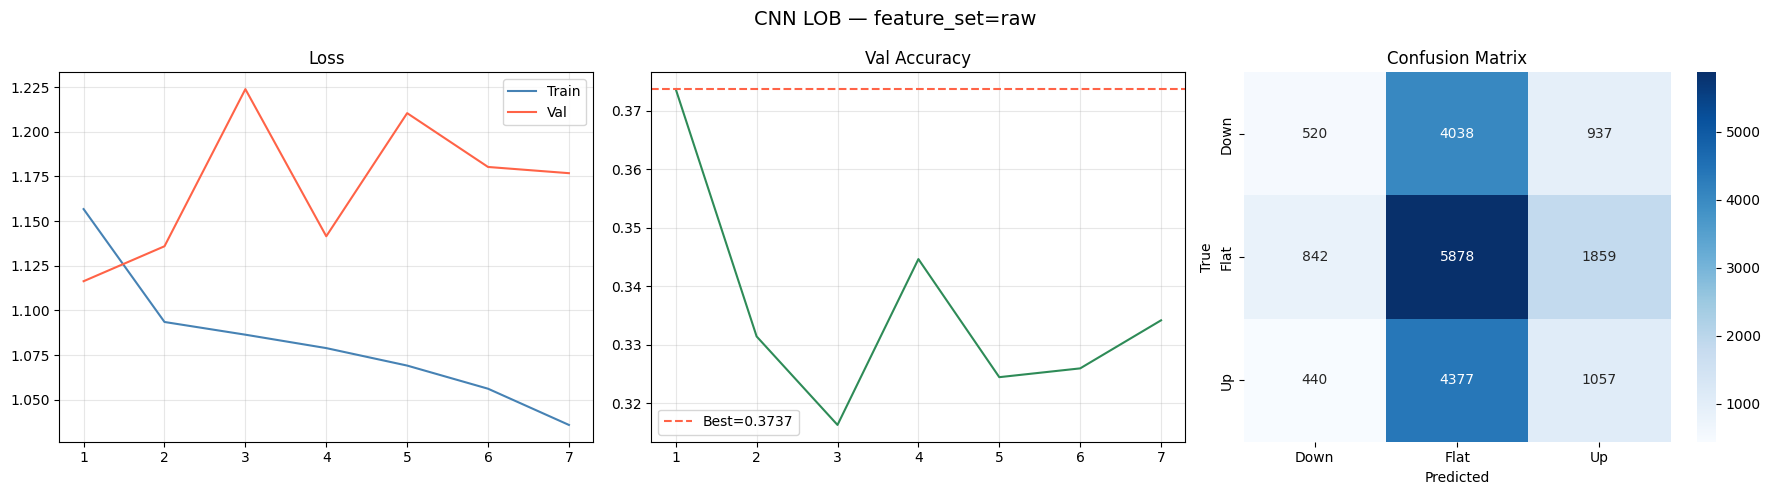

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Training  (identical to Transformer notebook)
# ══════════════════════════════════════════════════════════════════════════════
def train(model, train_loader, test_loader, class_w):
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        # ── train ──
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        # ── validate ──
        model.eval(); vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(Xb)
                vloss  += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total   += len(yb)
        val_loss = vloss / total
        val_acc  = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Ep {epoch:3d}/{EPOCHS} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc, patience_cnt = val_acc, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
                break

    model.load_state_dict(best_state)
    return history, best_acc


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Evaluation  (identical to Transformer notebook)
# ══════════════════════════════════════════════════════════════════════════════
def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            all_preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))
    return y_pred, y_true


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Plots  (identical to Transformer notebook)
# ══════════════════════════════════════════════════════════════════════════════
def plot_results(history, y_pred, y_true, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"CNN LOB — {title}", fontsize=14)

    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    best = max(history["val_acc"])
    axes[1].plot(ep, history["val_acc"], color="seagreen")
    axes[1].axhline(best, color="tomato", linestyle="--", label=f"Best={best:.4f}")
    axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
                xticklabels=["Down", "Flat", "Up"],
                yticklabels=["Down", "Flat", "Up"])
    axes[2].set_title("Confusion Matrix")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Run pipeline
# ══════════════════════════════════════════════════════════════════════════════
def run_cnn(feature_set: str):
    """
    Full CNN pipeline in one call.

    Parameters
    ----------
    feature_set : "full" | "pca" | "raw"
        Controls which features are fed to the CNN.
        Reads X_final, Y_final (and df for "raw") from the notebook scope.

    Architecture summary
    --------------------
    Input (B, T=30, F)
      → permute → (B, F, T)
      → Conv1d projection → (B, 64, T)
      → 3 × ResidualBlock1D  (channels: 64→128→256→256)
      → 3 × TemporalBlock (dilated causal, dilation 1/2/4)
      → GlobalAveragePool → (B, 256)
      → Linear head → (B, 3)

    Key differences vs Transformer
    --------------------------------
    • Convolutions capture local temporal patterns efficiently
    • Dilated blocks give exponentially growing receptive field (TCN-style)
    • No attention — faster, less memory, often competitive on short sequences
    • Residual connections prevent gradient vanishing in deeper stacks
    """
    print("=" * 60)
    print(f"  CNN LOB — feature_set = '{feature_set}'")
    print("=" * 60)

    X, y                       = select_features(feature_set)
    train_ld, test_ld, class_w = build_loaders(X, y)
    model                      = build_model(n_features=X.shape[1])

    print("\n--- Training ---")
    history, best_acc = train(model, train_ld, test_ld, class_w)

    print("\n--- Evaluation ---")
    y_pred, y_true = evaluate(model, test_ld)

    plot_results(history, y_pred, y_true, title=f"feature_set={feature_set}")

    return model, history


# ══════════════════════════════════════════════════════════════════════════════
#  ★  ENTRY POINT — change FEATURE_SET at the top, then run this cell  ★
# ══════════════════════════════════════════════════════════════════════════════
model_cnn, history_cnn = run_cnn(FEATURE_SET)

  CNN LOB — feature_set = 'pca'
Feature set : PCA only  (30 components)
X shape: (99882, 30)  |  y shape: (99882,)
Train samples: 79,876  |  Test samples: 19,948
Class weights (down/flat/up): [1.025 0.935 1.048]
Model params: 1,656,899  |  Input features: 30

--- Training ---
Ep   1/30 | Train Loss 1.1807 | Val Loss 1.0991 | Val Acc 0.3969
Ep   2/30 | Train Loss 1.0943 | Val Loss 1.1132 | Val Acc 0.3734
Ep   3/30 | Train Loss 1.0930 | Val Loss 1.1111 | Val Acc 0.3481
Ep   4/30 | Train Loss 1.0859 | Val Loss 1.1317 | Val Acc 0.2973
Ep   5/30 | Train Loss 1.0783 | Val Loss 1.1347 | Val Acc 0.3014
Ep   6/30 | Train Loss 1.0664 | Val Loss 1.1106 | Val Acc 0.3552
Ep   7/30 | Train Loss 1.0508 | Val Loss 1.1394 | Val Acc 0.3572
Early stop at epoch 7. Best val acc: 0.3969

--- Evaluation ---
              precision    recall  f1-score   support

        Down       0.06      0.00      0.00      5495
        Flat       0.42      0.86      0.57      8579
          Up       0.24      0.09      0.

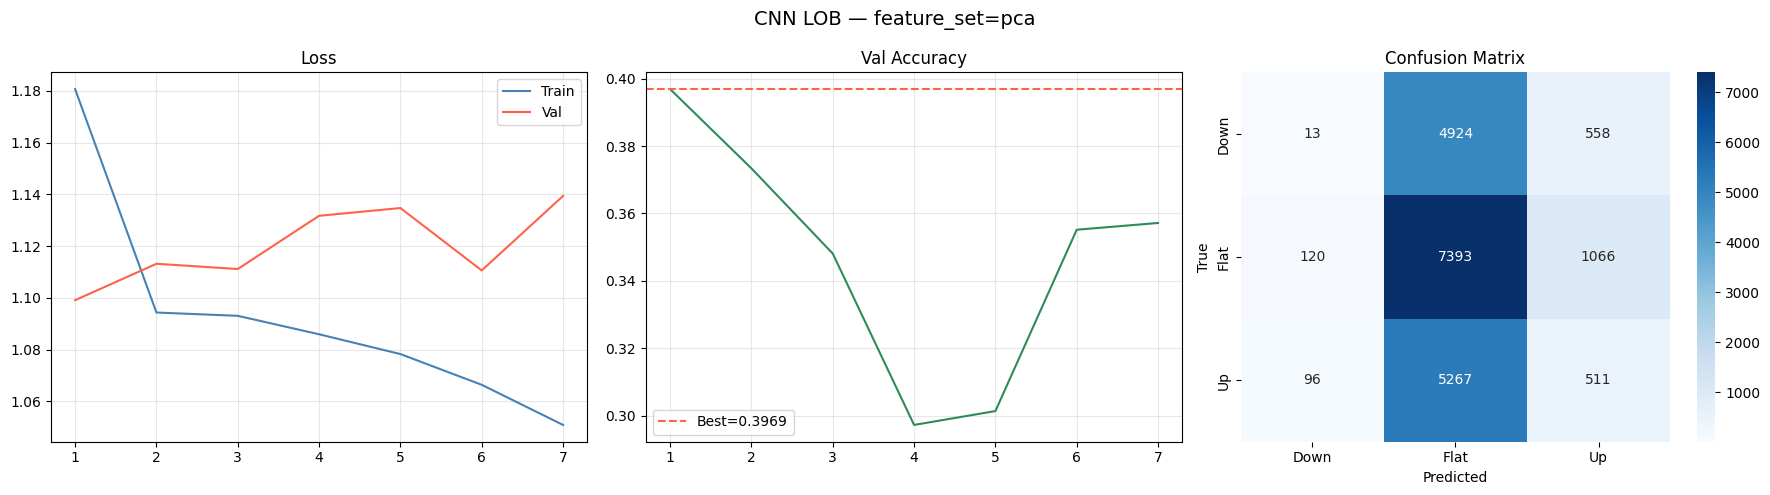

In [9]:
FEATURE_SET = "pca"
model, history = run_cnn(FEATURE_SET)

  CNN LOB — feature_set = 'full'
Feature set : FULL  (PCA + market state)
X shape: (99882, 45)  |  y shape: (99882,)
Train samples: 79,876  |  Test samples: 19,948
Class weights (down/flat/up): [1.025 0.935 1.048]
Model params: 1,657,859  |  Input features: 45

--- Training ---
Ep   1/30 | Train Loss 1.1528 | Val Loss 1.1148 | Val Acc 0.4121
Ep   2/30 | Train Loss 1.0865 | Val Loss 1.1344 | Val Acc 0.3441
Ep   3/30 | Train Loss 1.0778 | Val Loss 1.1176 | Val Acc 0.3855
Ep   4/30 | Train Loss 1.0712 | Val Loss 1.1490 | Val Acc 0.3532
Ep   5/30 | Train Loss 1.0608 | Val Loss 1.1982 | Val Acc 0.3215
Ep   6/30 | Train Loss 1.0444 | Val Loss 1.2235 | Val Acc 0.3275
Ep   7/30 | Train Loss 1.0252 | Val Loss 1.2430 | Val Acc 0.3359
Early stop at epoch 7. Best val acc: 0.4121

--- Evaluation ---
              precision    recall  f1-score   support

        Down       0.46      0.02      0.03      5495
        Flat       0.43      0.85      0.57      8579
          Up       0.30      0.14      

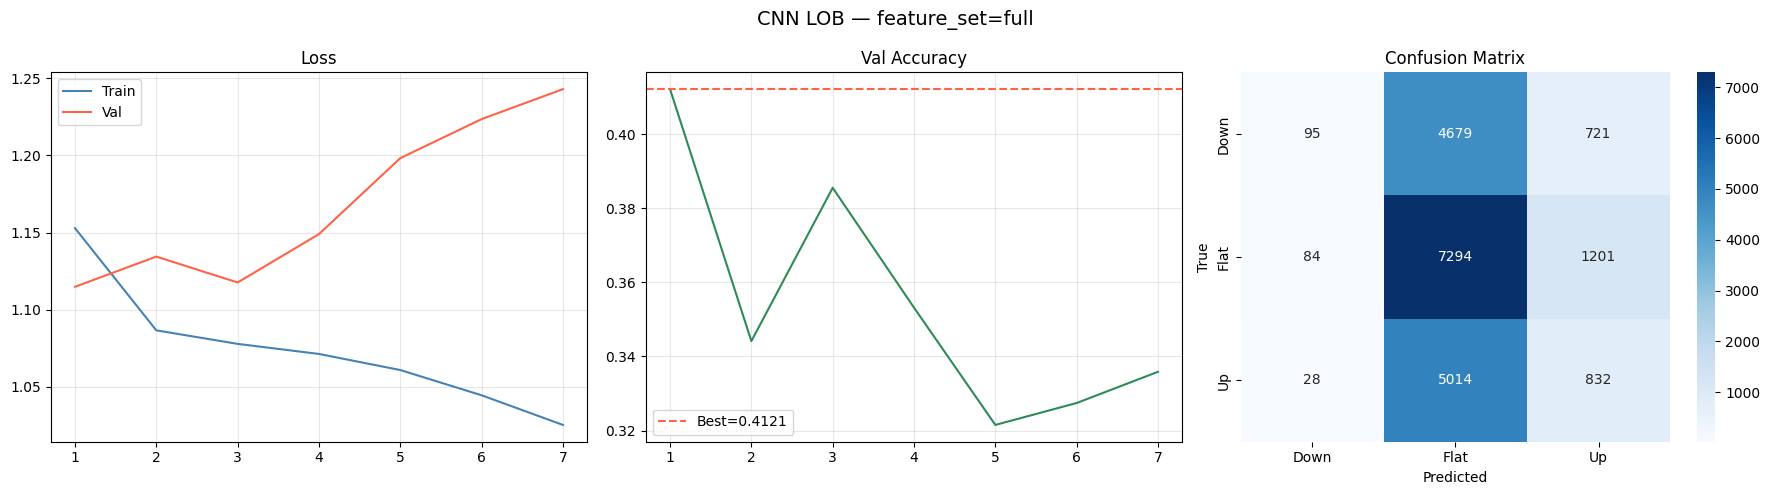

In [10]:
FEATURE_SET = "full"
model, history = run_cnn(FEATURE_SET)